## Seminar 00. Introduction to Jupyter Notebook — Data Processing

**Importing the required libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import interpolate
from scipy.signal import savgol_filter
from scipy.integrate import cumulative_trapezoid
import scipy.signal as sig

**Engine parameters**

In [2]:
D = 0.265        # cylinder bore, m
S = 0.310        # piston stroke, m
n_mex = 0.82956  # mechanical efficiency
rpm = 1000         # engine speed, rpm
icyl = 12        # number of cylinders
eps = 17.5       # compression ratio
lamb = 0.235     # R/L

**Others constants**  

In [3]:
Rm = 8.314        # universal gas constant

**Importing the working process file (1D-calc)**

In [4]:
filename = 'engine450hp.ind'
IndDiag = pd.read_csv(filename, skiprows=list(range(17)) + [18], sep=r'\s+', engine='python', encoding='latin1')
IndDiag.head()

,Fi,Pc,Tc,V,Alf_w,P_1ring,G_bb,P_pist,x
0,180.0,4.53,369.4,0.018319,581.7,2.0367,0.000867,0.000,2.000000e+25
1,181.0,4.53,369.6,0.018318,582.2,2.0386,0.000868,0.018,2.000000e+25
2,182.0,4.54,369.8,0.018315,582.7,2.0406,0.000869,0.073,2.000000e+25
3,183.0,4.55,369.9,0.018310,583.3,2.0426,0.000870,0.165,2.000000e+25
4,184.0,4.55,370.2,0.018303,583.8,2.0447,0.000871,0.293,2.000000e+25


## 1. Simple operation - data proccedings

### Assignment and mathematical operations

In [5]:
Fi1d   = IndDiag['Fi']
Pc1d   = IndDiag['Pc']*1e5
Tc1d   = IndDiag['Tc']
Vks    = IndDiag['V']
htc    = IndDiag['Alf_w']
HR     = IndDiag['x']

In [6]:
Vh=np.pi*D*D/4*S
print('Engine displacement, %2.4E' % Vh)

Engine displacement, 1.7098E-02


In [7]:
print('Maximum cylinder pressure Pz, MPa %2.2f' % (max(Pc1d) / 1e6))

Maximum cylinder pressure Pz, MPa 19.48


In [8]:
print('Maximum cycle temperature Tz, K %2.2f' % max(Tc1d))

Maximum cycle temperature Tz, K 1464.20


### Engine performance

Indicated work per cycle:

$$ L_{i} = \oint p \, dV $$

$$ p_{i} = \frac{L_{i}}{V_h} $$


In [9]:
# Indicated work per cycle
Li = 0
dFi = 1
for i in range(len(Pc1d) - 1):
    Li = Li + Pc1d[i] * (Vks[i + 1] - Vks[i]) / dFi

print('Indicated cycle work, W Li %2.2f' % Li)
print('Indicated mean pressure Pi, bar %2.2f' % (Li / Vh / 1e5))

Ni = Li * icyl *rpm / 120 / 1000
print('Indicated engine power, kW %2.2f' % Ni)
print('Brake mean effective pressure Pe, bar %2.2f' % (Li * n_mex / Vh / 1e5))
print('Brake engine power, kW %2.2f' % (Ni * n_mex))

Indicated cycle work, W Li 46552.01
Indicated mean pressure Pi, bar 27.23
Indicated engine power, kW 4655.20
Brake mean effective pressure Pe, bar 22.59
Brake engine power, kW 3861.77


### Determining the combustion chamber volume

Current combustion chamber volume:

$$
V(\phi) = V_c + V_h - \frac{\pi D^2}{4} \left( (1 - \cos \phi) - \frac{\lambda}{4}(1 - \cos(2\phi)) \right)
$$

**Vectorization of calculations**

In [10]:
Vc=Vh/(eps-1)
Fi = np.arange(0, 720)
V2Fi=Vh+Vc-Vh/S*(S/2)*((1-np.cos(np.deg2rad(Fi)))-(lamb/4)*(1-np.cos(2*np.deg2rad(Fi))))
epstest = max(V2Fi)/min(V2Fi)
round(epstest,2)

17.5

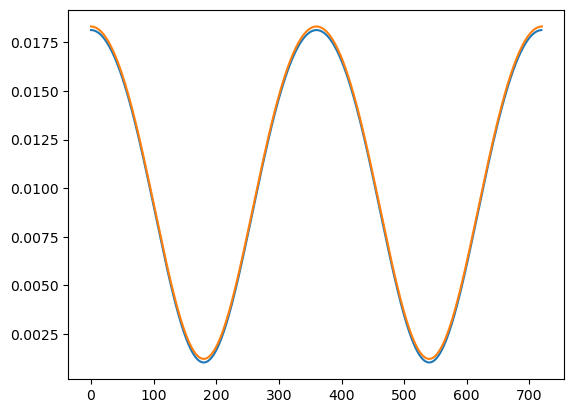

In [11]:
plt.plot(V2Fi)
plt.plot(Vks)

### Functions

In [12]:
def Vcalc(Fi):
    deg = Fi*np.pi/180
    Vc=Vh/(eps-1)
    return Vh+Vc-Vh/S*(S/2)*((1-np.cos(deg))-(lamb/4)*(1-np.cos(2*deg)))    

In [13]:
Vcalc(75)

0.012735046353158253

### Plotting graphs

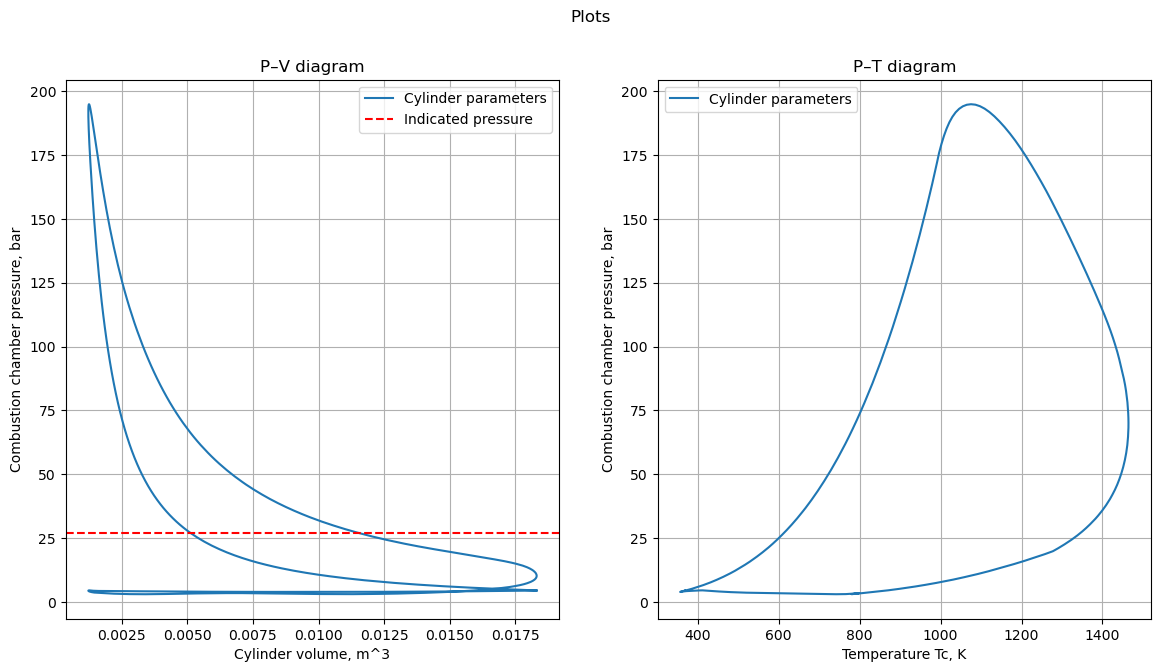

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# title
fig.suptitle('Plots')
ax[0].set_title('P–V diagram')
ax[1].set_title('P–T diagram')

# plots
ax[0].plot(Vks, Pc1d / 1e5, label='Cylinder parameters')
ax[0].axhline(y=Li / Vh / 1e5, color='r', linestyle='dashed', label='Indicated pressure')
ax[1].plot(Tc1d, Pc1d / 1e5, label='Cylinder parameters')

# axes
ax[0].set_ylabel('Combustion chamber pressure, bar')
ax[0].set_xlabel('Cylinder volume, m^3')
ax[1].set_ylabel('Combustion chamber pressure, bar')
ax[1].set_xlabel('Temperature Tc, K')

[[a.legend(), a.grid()] for a in ax]
plt.show()

You can use functions for this — that is, the plotting routine together with its settings can be placed inside a function body, and then only the variable values need to be passed to it.

In [15]:
def plot_curve(curve, title, labels):
    plt.figure(figsize=(5,5))
    plt.title (title)
    plt.plot(curve)
    plt.ylabel(labels[0], fontsize=14)
    plt.xlabel(labels[1], fontsize=14)
    plt.show()

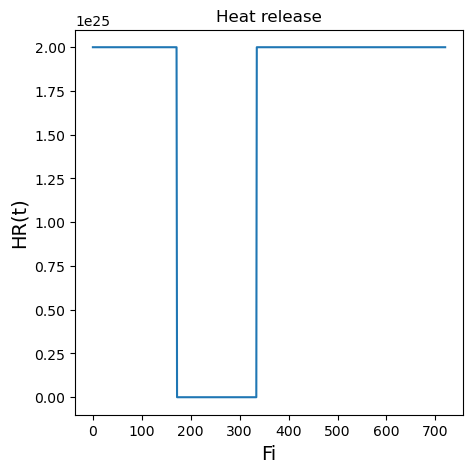

In [16]:
plot_curve(HR, 'Heat release', ['HR(t)', 'Fi'])

### Boolean indexing

**We need to get rid of the 1e25 values**

In [17]:
HR[HR>100] = 0

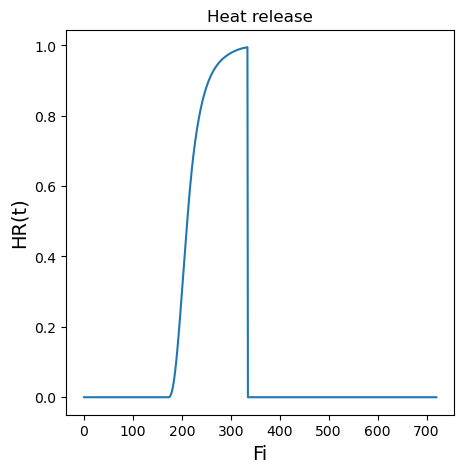

In [18]:
plot_curve(HR, 'Heat release', ['HR(t)', 'Fi'])

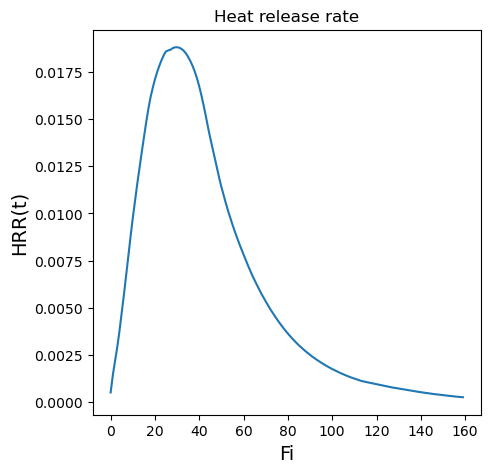

In [19]:
plot_curve(np.gradient(HR)[HR>0][:-1], 'Heat release rate', ['HRR(t)', 'Fi'])

## 2. Experimental data

###  Experimental cylinder pressure data

We will work with experimental cylinder pressure data from 14 engine cycles; the data have already been labeled.

In [20]:
exp = pd.read_csv('IndDiagExp01.csv', encoding='latin-1', delimiter=',')
exp['Fi_deg'] = exp['Fi_deg'] +360
exp.head(5)

,Fi_deg,Pz 1,Pz 2,Pz 3,Pz 4,Pz 5,Pz 6,Pz 7,Pz 8,Pz 9,Pz 10,Pz 11,Pz 12,Pz 13,Pz 14
0,-171.280000,5.889545,7.439443,5.927579,5.707999,5.592402,6.513900,5.553394,5.752286,6.040520,7.928765,6.485551,5.203112,5.220912,6.263854
1,-171.081809,6.481532,7.216028,5.911507,5.541448,5.464857,6.145986,5.917485,5.888261,5.896877,7.696960,6.445414,5.403205,5.438102,6.208395
2,-170.883617,6.079407,7.000525,5.847283,5.273299,5.013560,6.119900,5.791228,5.849329,5.966900,7.774807,6.445317,5.738631,5.470340,6.004762
3,-170.685426,6.019278,7.773405,5.726893,5.288525,5.083200,6.498847,5.518945,5.327309,5.779773,7.957263,6.085828,5.512632,5.478400,5.553185
4,-170.487234,6.120460,6.743725,5.486296,5.653583,5.387550,6.388070,5.475034,5.419861,6.786419,8.164607,5.876011,5.587635,5.398048,5.652408


In [21]:
pz_columns = ['Pz 1', 'Pz 2', 'Pz 3', 'Pz 4', 'Pz 5', 'Pz 6', 'Pz 7', 'Pz 8', 'Pz 9', 'Pz 10', 'Pz 11', 'Pz 12', 'Pz 13', 'Pz 14']
exp[pz_columns] = exp[pz_columns]*1e5     # pressure is originally recorded in bar

Let us average the data over the cycles and add a new column.

In [22]:
exp['Pexp'] = exp[pz_columns].mean(axis=1)
exp.head(5)

,Fi_deg,Pz 1,Pz 2,Pz 3,Pz 4,Pz 5,Pz 6,Pz 7,Pz 8,Pz 9,Pz 10,Pz 11,Pz 12,Pz 13,Pz 14,Pexp
0,-171.280000,588954.4741,743944.3256,592757.9119,570799.8632,559240.1816,651389.9564,555339.3557,575228.5765,604051.9833,792876.5211,648555.0590,520311.2147,522091.1671,626385.4434,610851.859543
1,-171.081809,648153.1728,721602.8454,591150.7070,554144.7919,546485.6686,614598.6451,591748.4943,588826.0865,589687.7114,769695.9963,644541.3645,540320.5391,543810.1771,620839.5492,611828.982086
2,-170.883617,607940.7494,700052.5094,584728.3302,527329.9461,501355.9977,611990.0177,579122.8408,584932.9123,596690.0052,777480.7318,644531.6796,573863.0563,547033.9725,600476.2130,602680.640143
3,-170.685426,601927.8498,777340.5240,572689.3264,528852.5084,508320.0176,649884.7236,551894.4629,532730.9168,577977.2570,795726.2535,608582.7576,551263.2448,547839.9884,555318.4539,597167.734621
4,-170.487234,612046.0147,674372.5300,548629.5729,565358.2827,538754.9863,638807.0374,547503.3636,541986.0964,678641.9246,816460.6668,587601.1395,558763.5407,539804.7550,565240.8233,600997.909564


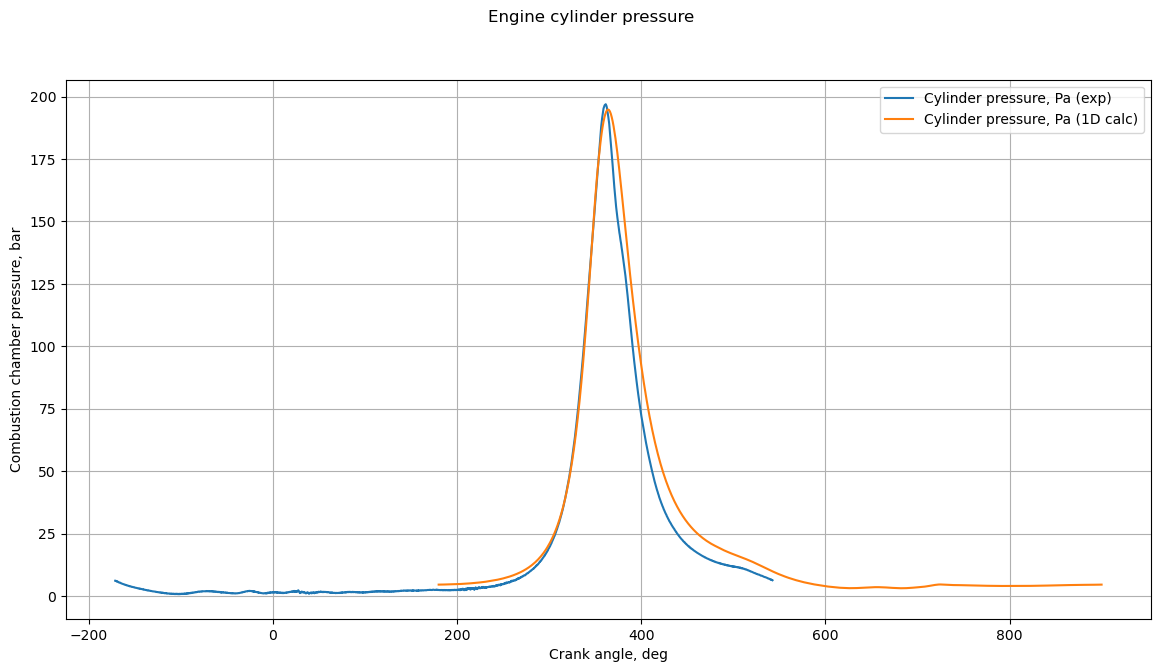

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# title
fig.suptitle('Engine cylinder pressure')

# plots
plt.plot(exp['Fi_deg'], exp['Pexp'] / 1e5, label='Cylinder pressure, Pa (exp)')
plt.plot(Fi1d, Pc1d / 1e5, label='Cylinder pressure, Pa (1D calc)')

# axes
plt.ylabel('Combustion chamber pressure, bar')
plt.xlabel('Crank angle, deg')
plt.legend()
plt.grid()
plt.show()

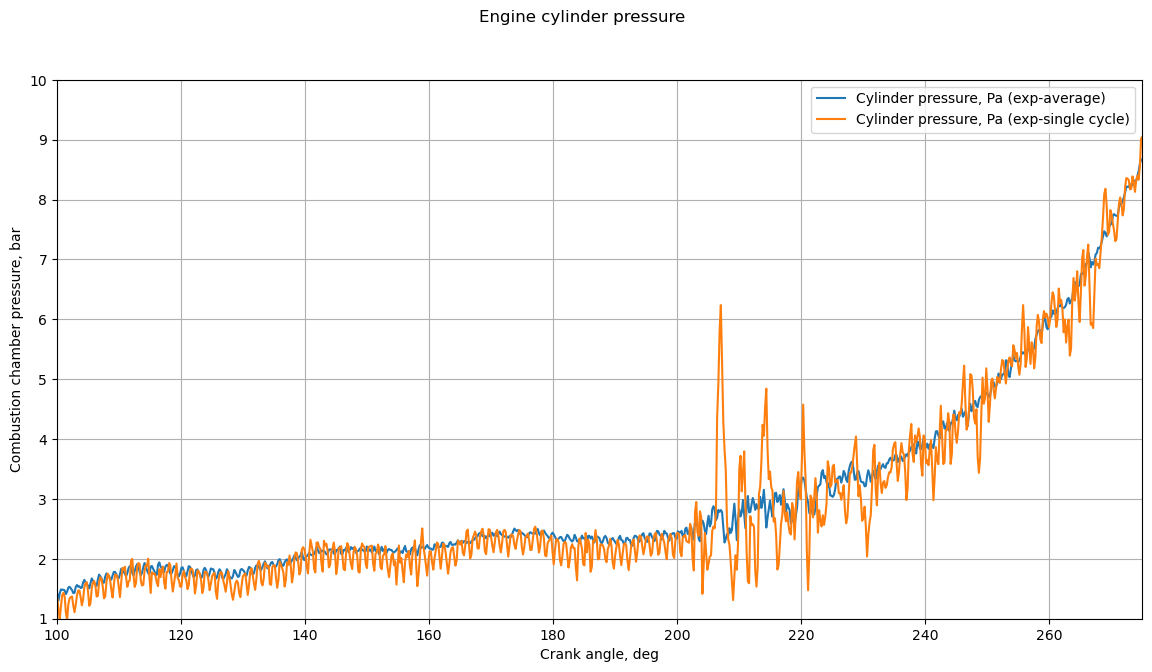

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# title
fig.suptitle('Engine cylinder pressure')

# plots
plt.plot(exp['Fi_deg'], exp['Pexp'] / 1e5, label='Cylinder pressure, Pa (exp-average)')
plt.plot(exp['Fi_deg'], exp['Pz 1'] / 1e5, label='Cylinder pressure, Pa (exp-single cycle)')

# axes
plt.ylabel('Combustion chamber pressure, bar')
plt.xlabel('Crank angle, deg')
plt.xlim([100, 275])
plt.ylim([1, 10])
plt.legend()
plt.grid()
plt.show()

Averaging makes it possible to smooth the values. Let us see what the **dP/dFi** plot looks like.

In [25]:
dPdFi = np.gradient(exp['Pexp'], exp['Fi_deg'])

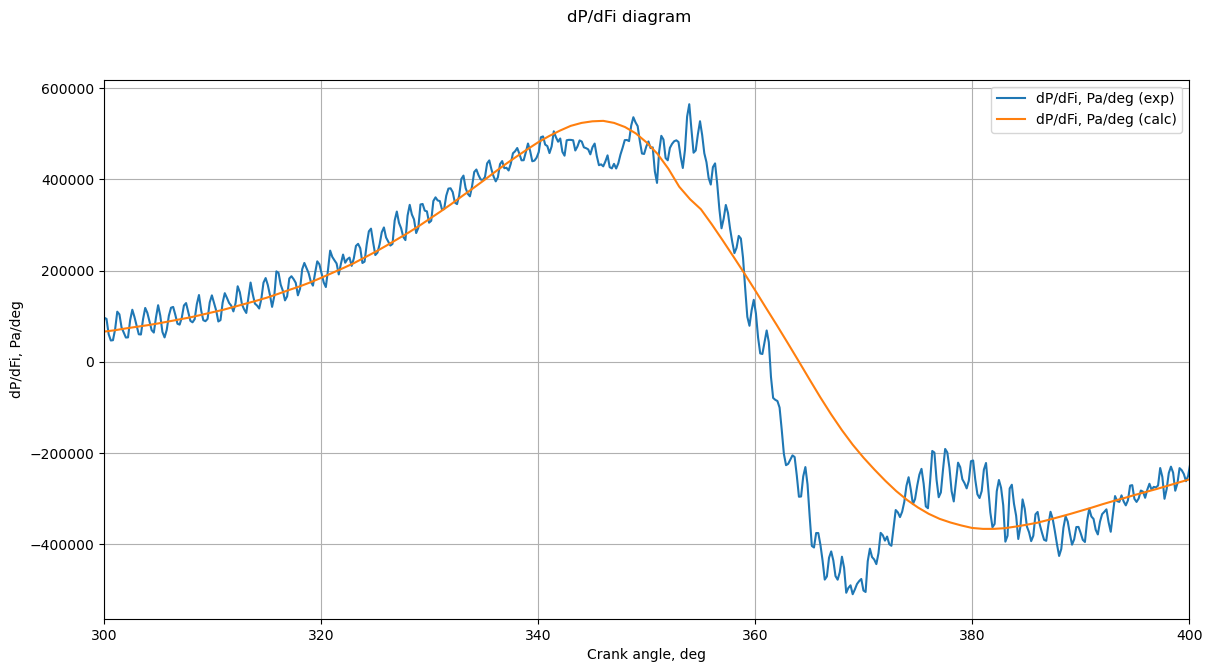

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
# title
fig.suptitle('dP/dFi diagram')

# plots
plt.plot(exp['Fi_deg'], dPdFi, label='dP/dFi, Pa/deg (exp)')
plt.plot(Fi1d, np.gradient(Pc1d, Fi1d), label='dP/dFi, Pa/deg (calc)')

# axes
plt.ylabel('dP/dFi, Pa/deg')
plt.xlabel('Crank angle, deg')
plt.legend()
plt.xlim([300, 400])
plt.grid()
plt.show()

There are studies that also examine the variation of the second derivative of pressure with respect to crank angle to identify the combustion process.

The main thing is not to overdo the smoothing; for HRR reconstruction, we will use the smoothed values.

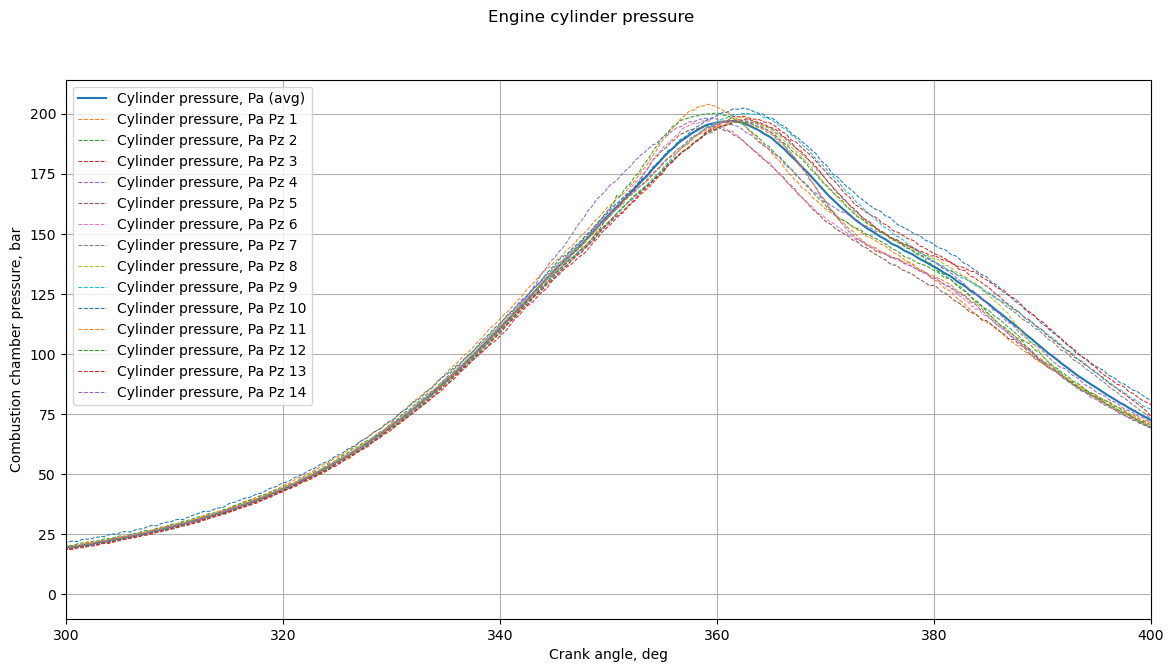

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# title
fig.suptitle('Engine cylinder pressure')

# plots
plt.plot(exp['Fi_deg'], exp['Pexp'] / 1e5, label='Cylinder pressure, Pa (avg)')
for cycle in pz_columns:
    plt.plot(exp['Fi_deg'], exp[cycle] / 1e5, linestyle='--', linewidth=0.75, label=f'Cylinder pressure, Pa {cycle}')
# axes
plt.ylabel('Combustion chamber pressure, bar')
plt.xlabel('Crank angle, deg')
plt.xlim([300, 400])
# plt.ylim([1, 10])
plt.legend()
plt.grid()
plt.show()

### Extra topic about Noised data filtering

Давайте посмотрим на какой-нибудь сигнал - book 'Data-Driven Science and Engineering: Machine Learning, Dynamical Systems, and Control' 
by Steven L. Brunton (Author), J. Nathan Kutz (Author)

In [28]:
# Create a simple signal with two frequencies
dt = 0.001
t = np.arange(0,1,dt)
f_clean = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t)          # Sum of 2 frequencies
f = f_clean + 2.5*np.random.randn(len(t))                       # Add some noise

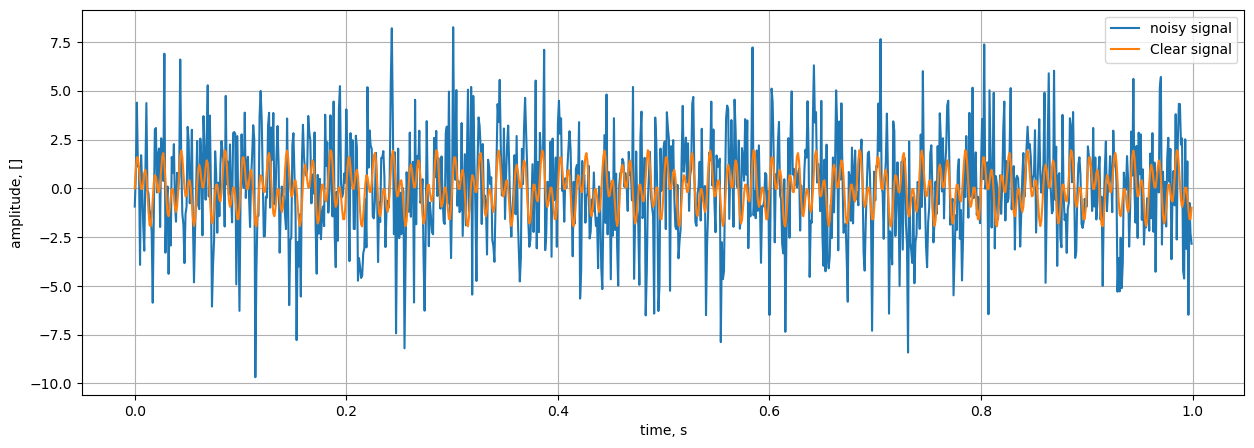

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(t, f, label='noisy signal')
plt.plot(t, f_clean, label='Clear signal')
plt.xlabel('time, s')
plt.ylabel('amplitude, []')
plt.legend()
plt.grid()
plt.show()

In [30]:
## Compute the Fast Fourier Transform (FFT)
n = len(t)
fhat = np.fft.fft(f,n)                     # Compute the FFT
PSD = fhat * np.conj(fhat) / n             # Power spectrum (power per freq)
freq = (1/(dt*n)) * np.arange(n)           # Create x-axis of frequencies in Hz
L = np.arange(1,np.floor(n/2),dtype='int') # Only plot the first half of freqs

C:\Users\int\.conda\envs\ICengine_theory_st\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\int\.conda\envs\ICengine_theory_st\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


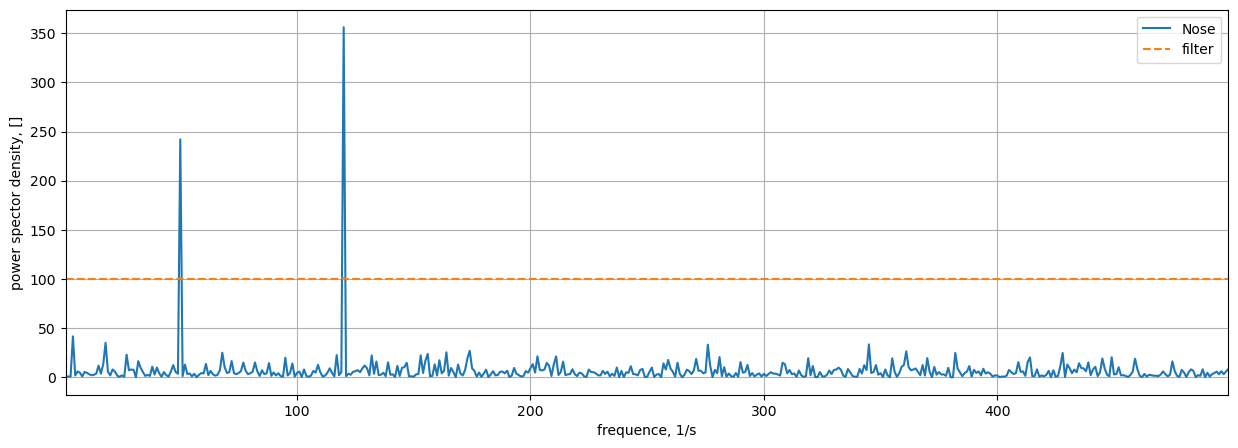

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(freq[L], PSD[L], label='Nose')
plt.plot(freq[L], 100+(PSD[L]>100), linestyle = '--', label='filter')
plt.xlabel('frequence, 1/s')
plt.ylabel('power spector density, []')
plt.legend()
plt.grid()
plt.xlim(freq[L[0]],freq[L[-1]])
plt.show()

In [32]:
## Use the PSD to filter out noise
indices = PSD > 100       # Find all freqs with large power
PSDclean = PSD * indices  # Zero out all others
fhat = indices * fhat     # Zero out small Fourier coeffs. in Y
ffilt = np.fft.ifft(fhat) # Inverse FFT for filtered time signal

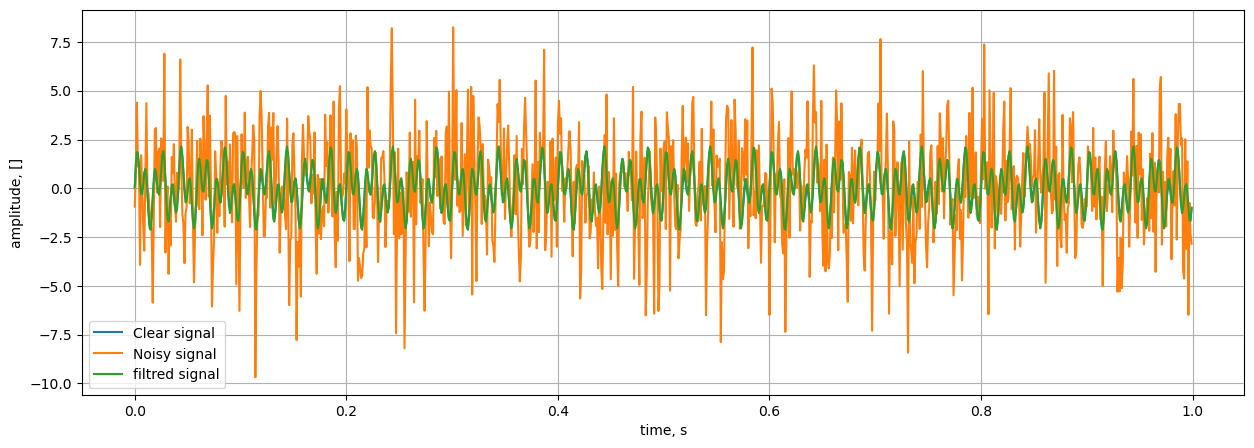

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(t, f_clean, label='Clear signal')
plt.plot(t, f, label='Noisy signal')
plt.plot(t, ffilt, label='filtred signal')
plt.xlabel('time, s')
plt.ylabel('amplitude, []')
plt.legend()
plt.grid()
plt.show()

Возьмем другие данные где например есть наводки от электрической сети (https://youtu.be/0TSvo2hOKo0?si=DEWzL07Vv3fsP37Y)

In [34]:
# Create a simple signal with two frequencies
signal = np.loadtxt('materials\\meter.txt')
signal = signal -np.mean(signal)
sample_rate = 800
t = np.arange(len(signal))/sample_rate                              # sampling rate (Hz)
dt = t[1] - t[0]

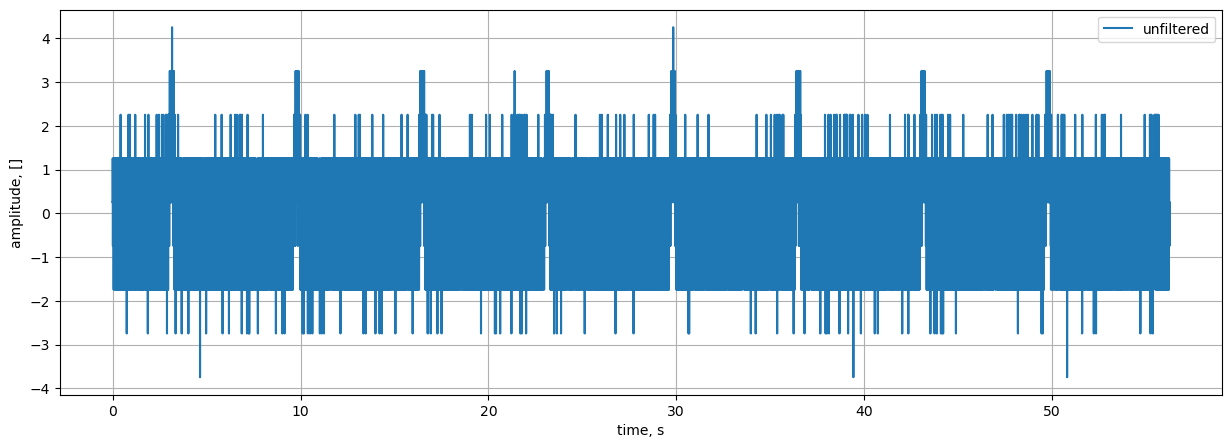

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(t, signal, label='unfiltered')
plt.xlabel('time, s')
plt.ylabel('amplitude, []')
plt.legend()
plt.grid()
plt.show()

In [36]:
## Compute the Fast Fourier Transform (FFT)
n = len(t)
fhat = np.fft.fft(signal,n)                # Compute the FFT
PSD = fhat * np.conj(fhat) / n             # Power spectrum (power per freq)
freq = (1/(dt*n)) * np.arange(n)           # Create x-axis of frequencies in Hz
L = np.arange(1,np.floor(n/2),dtype='int') # Only plot the first half of freqs

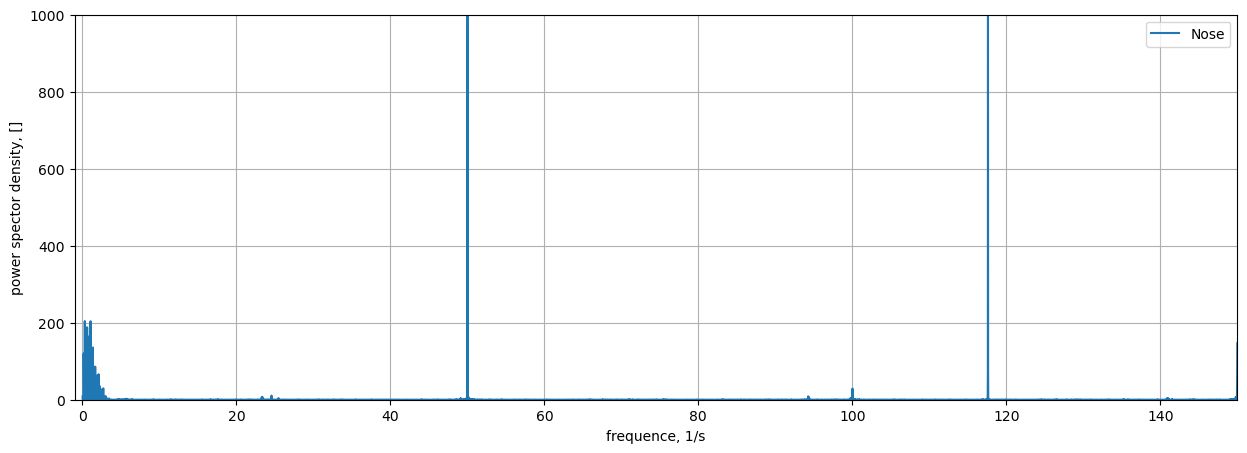

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(freq[L], (PSD[L]), label='Nose')
plt.xlabel('frequence, 1/s')
plt.ylabel('power spector density, []') 
plt.legend()
plt.xlim([-1, 150])
plt.ylim([0, 1000])
plt.grid()
plt.show()

Здесь проблема в том, что мы не может убрать данные по спектральной мощности сигнала, у нас тогда останется белый шум на 50Hz. В то время как наш сигнал от датчика низкочастотный 0-10 Hz примерно. А фильтр Savitzky–Golay как раз позволяет убрать высокочастотные данные.

Just in case, here is a video example of how this filter works.
https://youtu.be/1SvDZPvUo_I?si=st-Q4vaulbE5pJhD

На графики ниже пунктирыми линиями приведена область действия фильтра S-G в зависимости от ширины окна фильтрации

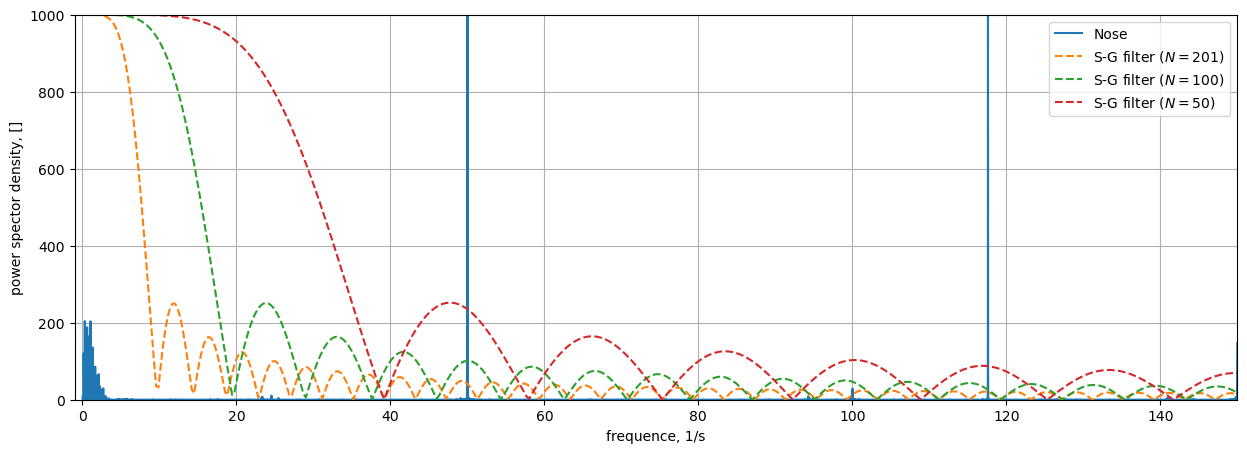

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(freq[L], (PSD[L]), label='Nose')
plt.xlabel('frequence, 1/s')
plt.ylabel('power spector density, []') 
for winl in [201, 100, 50]:
    h = sig.savgol_coeffs(window_length=winl, polyorder=5)
    f = np.fft.rfftfreq(fft_length, d=dt)
    H = np.abs(np.fft.rfft(h, fft_length))
    plt.plot(f, 1000*H, linestyle = '--', label='S-G filter ('+'$N=' + str(winl) + '$'+  ')')

plt.legend()
plt.xlim([-1, 150])
plt.ylim([0, 1000])
plt.grid()
plt.show()

Фильтр Savitzky–Golay уменьшает вклад высокочастотных компонентов, но не полностью от них избавляется

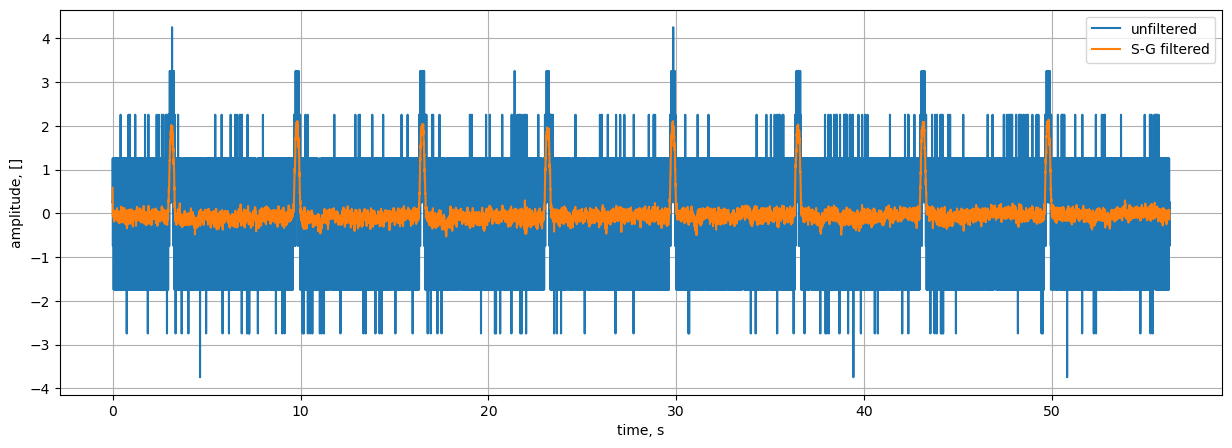

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(t, signal, label='unfiltered')
plt.plot(t, savgol_filter(signal,window_length =100 ,polyorder =6), label='S-G filtered')
plt.xlabel('time, s')
plt.ylabel('amplitude, []')
plt.legend()
plt.grid()
plt.show()

In [41]:
## convert to time step
dFi =exp['Fi_deg'][1] - exp['Fi_deg'][0]
omega =rpm*360/60
dt = dFi/omega
## Compute the Fast Fourier Transform (FFT)
n = len(exp['Fi_deg'])
freq = (1/(dt*n)) * np.arange(n)           # Create x-axis of frequencies in Hz
L = np.arange(1,np.floor(n/2),dtype='int') # Only plot the first half of freqs

In [42]:
# данные с индицирования
fhat_single = np.fft.fft(exp['Pz 1'],n)           # Compute the FFT
fhat_averaged = np.fft.fft(exp['Pexp'],n)           # Compute the FFT
PSD_s = fhat_single * np.conj(fhat_single) / n             # Power spectrum (power per freq)
PSD_a = fhat_averaged * np.conj(fhat_averaged) / n             # Power spectrum (power per freq)

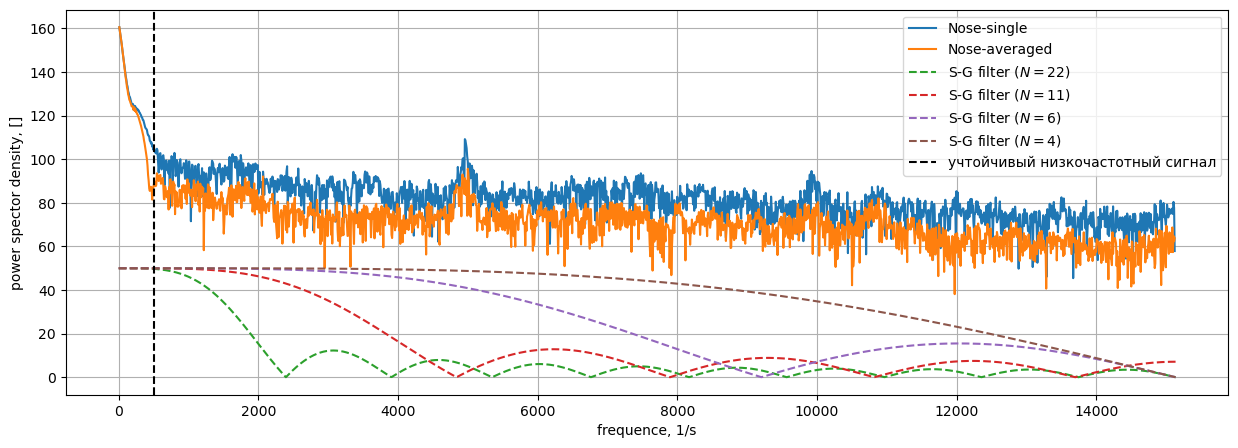

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(freq[L], 10*np.log10(PSD_s[L]), label='Nose-single')
plt.plot(freq[L], 10*np.log10(PSD_a[L]), label='Nose-averaged')
for winl in [22, 11, 6, 4]:
    h = sig.savgol_coeffs(window_length=winl, polyorder=3)
    f = np.fft.rfftfreq(fft_length, d=dt)
    H = np.abs(np.fft.rfft(h, fft_length))
    plt.plot(f, 50*H, linestyle = '--', label='S-G filter ('+'$N=' + str(winl) + '$'+  ')')
plt.axvline(500, linestyle='--', color='black', label='учтойчивый низкочастотный сигнал')
plt.xlabel('frequence, 1/s')
plt.ylabel('power spector density, []') 
plt.legend()
#plt.xlim([-1, 150])
#plt.ylim([-1, 1000])
plt.grid()
plt.show()

- оранжевая кривая после осреднения почти везде ниже синей, то есть случайная высокочастотная составляющая действительно уменьшилась;
- при этом общая форма спектра сохранилась — значит полезная низкочастотная структура сигнала не разрушена;
- пики около ~5 кГц и слабее около ~10 кГц все еще остаются, значит это уже не просто случайный шум одного цикла, а скорее устойчивая детерминированная составляющая

Отфильтруем сигнал и посмотрим как это скажется на dPdFi

In [44]:
PSG = []
dPSGdFi = []
for winl in [22, 11, 6, 4]:
    data = savgol_filter(exp['Pexp'], winl, 3)
    PSG.append(data)
    dPSGdFi.append(np.gradient(data, exp['Fi_deg']))

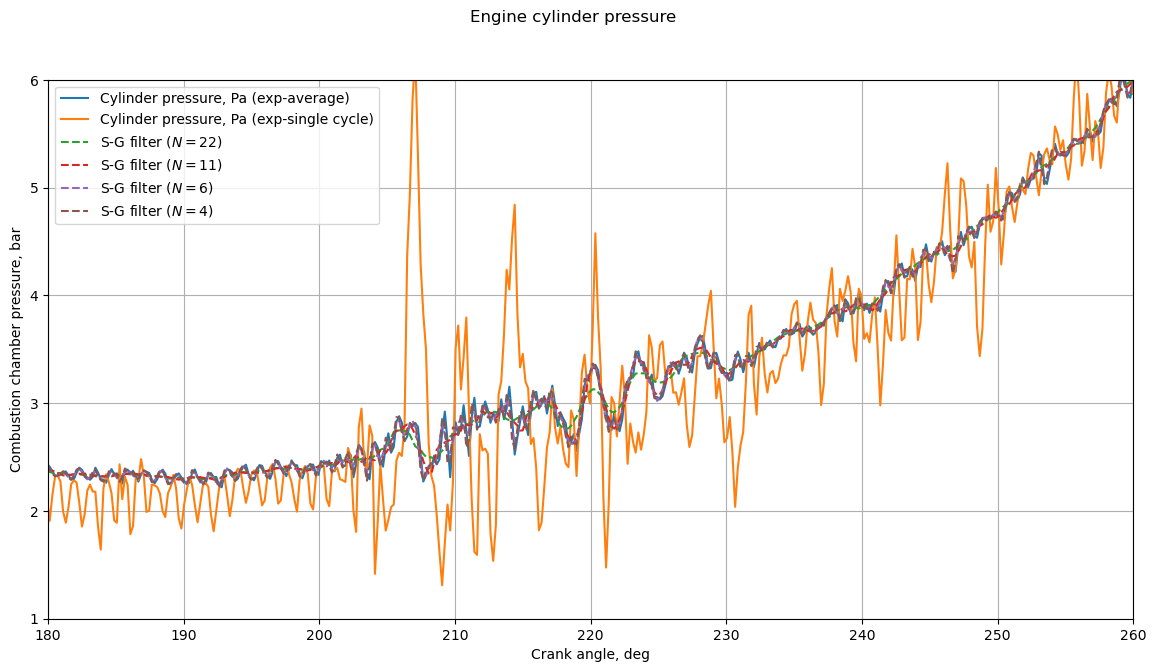

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
# title
fig.suptitle('Engine cylinder pressure')
# plots
plt.plot(exp['Fi_deg'], exp['Pexp'] / 1e5, label='Cylinder pressure, Pa (exp-average)')
plt.plot(exp['Fi_deg'], exp['Pz 1'] / 1e5, label='Cylinder pressure, Pa (exp-single cycle)')
for i, winl in enumerate([22, 11, 6, 4]):
    plt.plot(exp['Fi_deg'], PSG[i]/ 1e5, linestyle = '--', label='S-G filter ('+'$N=' + str(winl) + '$'+  ')')
# axes
plt.ylabel('Combustion chamber pressure, bar')
plt.xlabel('Crank angle, deg')
plt.xlim([180, 260])
plt.ylim([1, 6])
plt.legend()
plt.grid()
plt.show()

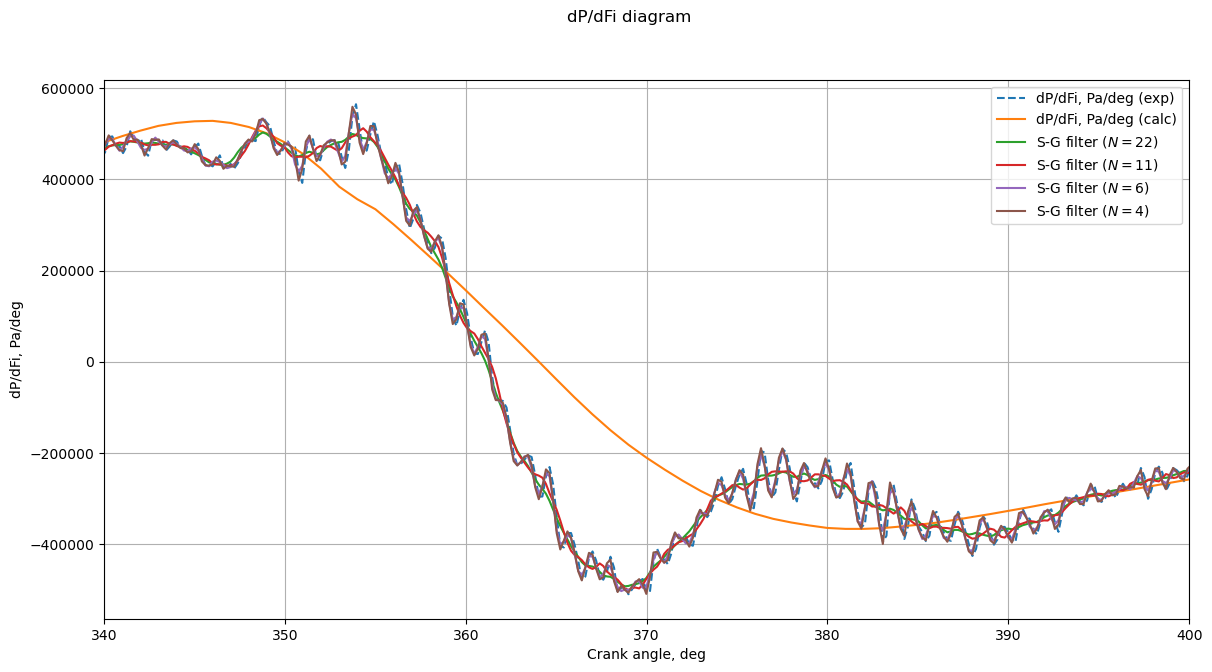

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
# title
fig.suptitle('dP/dFi diagram')
# plots
plt.plot(exp['Fi_deg'], dPdFi, label='dP/dFi, Pa/deg (exp)', linestyle = '--')
plt.plot(Fi1d, np.gradient(Pc1d, Fi1d), label='dP/dFi, Pa/deg (calc)')
for i, winl in enumerate([22, 11, 6, 4]):
    plt.plot(exp['Fi_deg'], dPSGdFi[i], linestyle = '-', label='S-G filter ('+'$N=' + str(winl) + '$'+  ')')
# axes
plt.ylabel('dP/dFi, Pa/deg')
plt.xlabel('Crank angle, deg')
plt.legend()
plt.xlim([340, 400])
plt.grid()
plt.show()

Использование преобразования Фурье и отсечки по спектральной плотности наиболее эффективно в тех случаях, когда задача состоит в выделении или подавлении известных частотных диапазонов, а полезный сигнал и помехи достаточно хорошо разделяются по частоте. Такой подход удобен для квазистационарных сигналов и задач частотного анализа. Однако для сигналов, содержащих локальные особенности, резкие переходы и характерные экстремумы, одной только спектральной фильтрации недостаточно, поскольку она не гарантирует сохранения формы сигнала. 

Поэтому при анализе индикаторных диаграмм и характеристик тепловыделения выбор фильтра должен контролироваться по физически значимым параметрам процесса сгорания, а не только по виду спектра.
Параметры фильтра для обработки индикаторной диаграммы следует выбирать не только по спектральным характеристикам сигнала, но и по степени сохранения сохраниния ее характерных точек. Спектральный анализ позволяет лишь предварительно оценить уровень высокочастотной составляющей и диапазон частот, в котором сосредоточен шум. Однако окончательная настройка фильтра должна выполняться по косвенным признакам искажения полезного сигнала.

К таким признакам относятся:

- смещение положения максимумов давления и тепловыделения;
- уменьшение или чрезмерное размытие амплитуды пиков;
- искажение формы фронта нарастания и спада;
- смещение характерных фаз сгорания (`CA10`, `CA50`, `CA90`);
- появление или исчезновение нефизичных локальных колебаний.

Таким образом, спектр следует рассматривать как вспомогательный инструмент предварительной оценки шумовой составляющей, тогда как окончательный выбор параметров фильтра должен основываться на критерии минимального искажения кривых `p(φ)`, `dp/dφ` и `dQ/dφ)`.



## Obtaining heat release characteristic data

In [47]:
Hu = 42.5*10**6           # let us assume the following value for the lower specific heating value

In [48]:
# since we do not have heat capacity data, we will use this value as a first approximation
cv = 25          

That also works

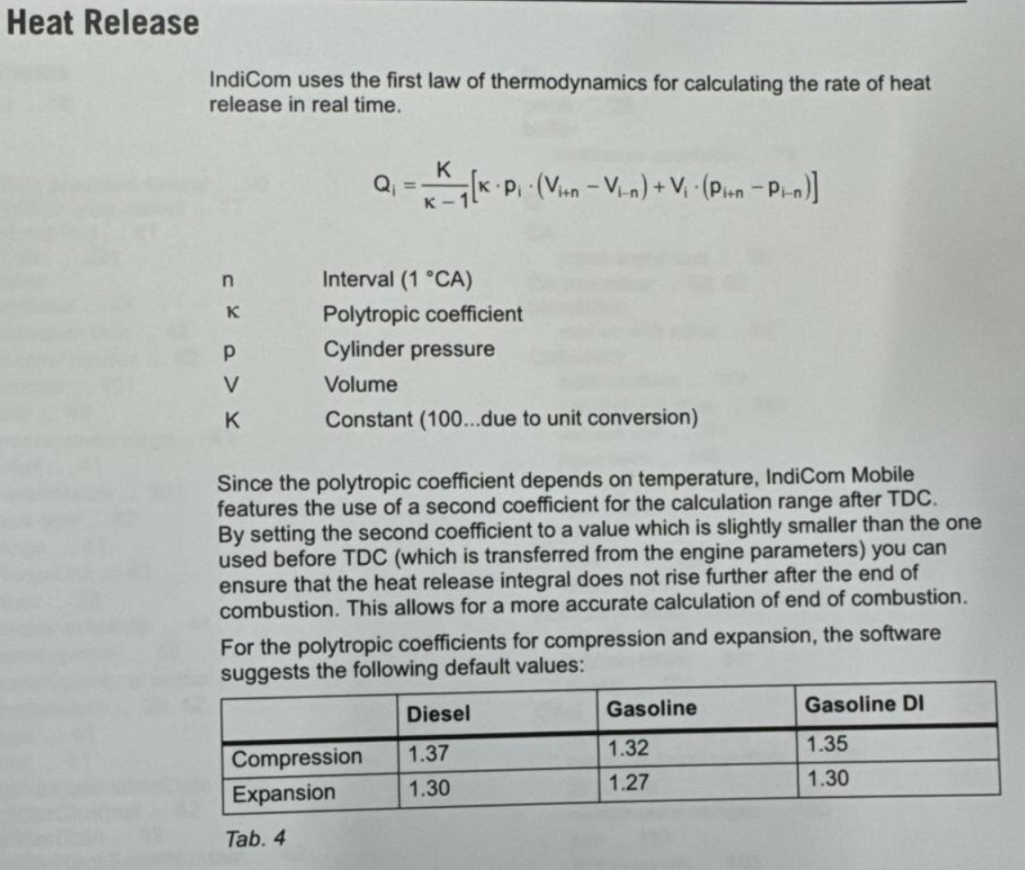

Let us define the terms for the First Law of Thermodynamics:

$$
\frac{dQ_{comb}}{d\phi} = \frac{dU}{d\phi} - \frac{dL}{d\phi} - \frac{dQ_w}{d\phi}
\qquad (1)
$$

$$
\frac{dU}{d\phi} = C_v \frac{d(MT)}{d\phi}
\quad | \quad pV = MRT \quad |
\quad = \frac{C_v}{R_m} \frac{d(pV)}{d\phi}
\qquad (2)
$$

$$
\frac{dL}{d\phi} = -p \frac{dV}{d\phi}
\qquad (3)
$$

Then the expression for the heat released during combustion takes the form:

$$
\frac{dQ_{comb}}{d\phi} =
\left( \frac{C_v}{R_m} + 1 \right) p \frac{dV}{d\phi}
+ \frac{C_v}{R_m} V \frac{dp}{d\phi}
- \frac{dQ_w}{d\phi}
\qquad (4)
$$

In [49]:
qc = 1.47e-03                                              # assume that the experimental cycle fuel delivery is as follows

In [50]:
# Используем для расчетов фильтрованные данные с окном 22
exp['Pexp_smooth'] = savgol_filter(exp['Pexp'], 22, 3)

In [51]:
Fi = exp['Fi_deg'].to_numpy()
Pc = exp['Pexp_smooth'].to_numpy()
V = Vcalc(Fi+180)
dVdFi = np.gradient(V, Fi)
dPdFi = np.gradient(Pc, Fi)
dQcdFi = (cv/Rm + 1) * Pc * dVdFi + (cv/Rm) * V * dPdFi

Plot of heat release $ \dfrac{dQ_{comb}}{d\phi} $ versus crank angle

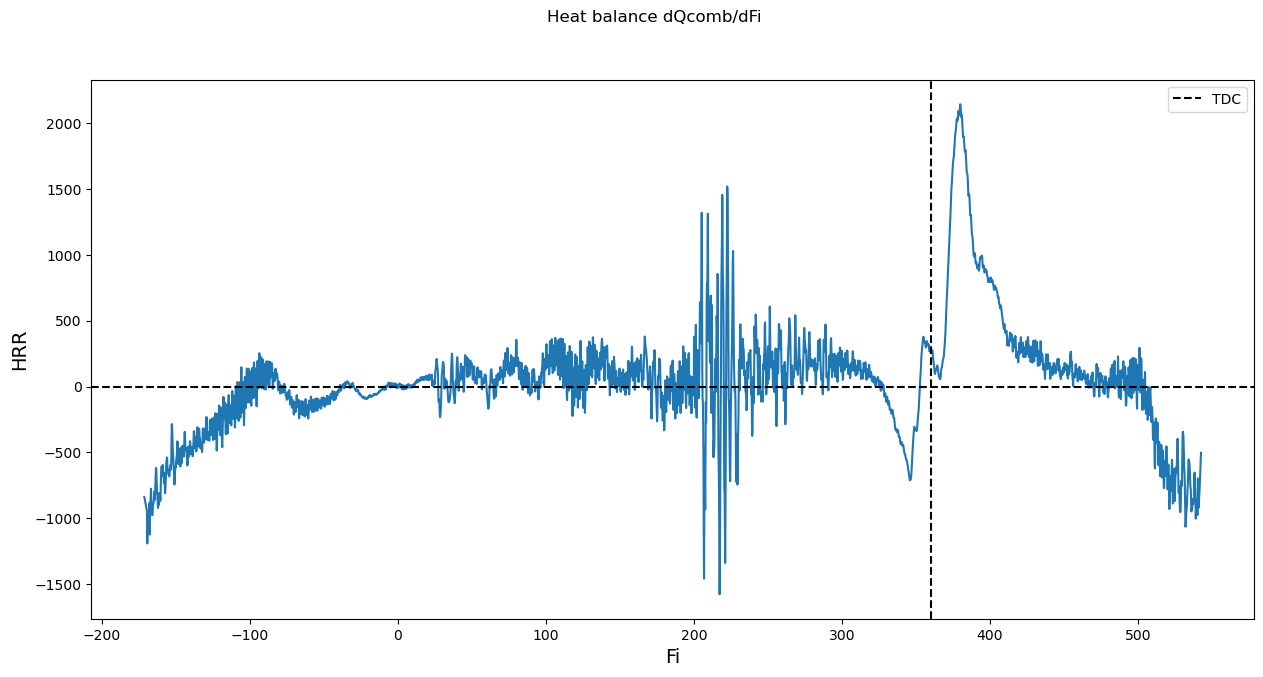

In [52]:
fig, ax = plt.subplots(figsize=(15, 7))
plt.suptitle('Heat balance dQcomb/dFi')
plt.plot(Fi, dQcdFi)
plt.ylabel('HRR', fontsize=14)
plt.xlabel('Fi', fontsize=14)
plt.axhline(0, linestyle='--', color='black')
plt.axvline(360, linestyle='--', color='black', label='TDC')
plt.legend()
plt.show()

Although the start of combustion is actually **7 crank-angle degrees before TDC**, it is reasonable to reconstruct the heat release characteristic using the **Wiebe function starting from 7 crank-angle degrees after TDC**.

The start of combustion was taken as the crank angle corresponding to **5%** of the cumulative heat release (**CA05**), and the end of combustion as the angle corresponding to **95%** of the cumulative heat release (**CA95**). This approach makes it possible to exclude the influence of the weakly pronounced initial and final stages of the process, which is especially important when analyzing experimental indicator diagrams.

In [53]:
strt = 2643
end = 3300

mask = (Fi >= Fi[strt]) & (Fi < Fi[end])
Qtot = cumulative_trapezoid(dQcdFi[strt:end], Fi[strt:end], initial=0)

CA05 = np.interp(0.05, Qtot / Qtot[-1], Fi[mask])
CA50 = np.interp(0.50, Qtot / Qtot[-1], Fi[mask])
CA95 = np.interp(0.95, Qtot / Qtot[-1], Fi[mask])

print(f'Start of combustion angle, Fi = {CA05:0.2f} deg')
print(f'End of combustion angle, Fi = {CA95:0.2f} deg')
print(f'Combustion duration, Fi = {(CA95 - CA05):0.2f} deg')

Start of combustion angle, Fi = 366.28 deg
End of combustion angle, Fi = 443.29 deg
Combustion duration, Fi = 77.01 deg


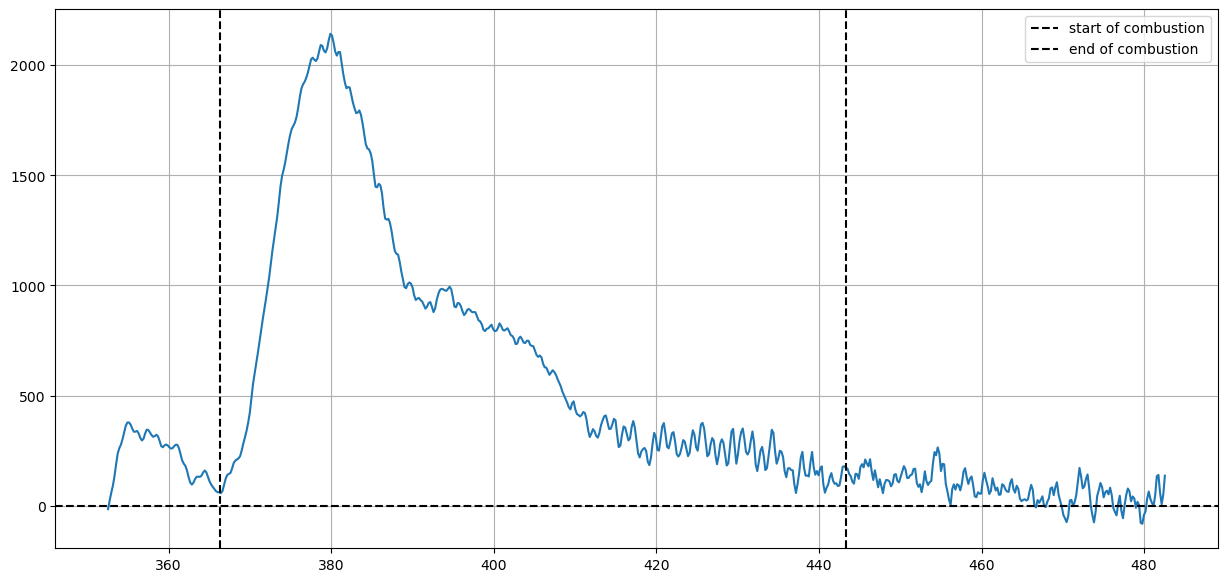

In [54]:
interval = np.arange(2643, 3300)
fig, ax = plt.subplots(figsize=(15, 7))
plt.plot(Fi[interval], dQcdFi[interval])
plt.axhline(0, linestyle="--", color='black')
plt.axvline(CA05, linestyle="--", color='black', label='start of combustion')
plt.axvline(CA95, linestyle="--", color='black', label='end of combustion')
plt.grid()
plt.legend()
plt.show()

In [55]:
f = interpolate.interp1d(Fi, dQcdFi)
fi = np.linspace(CA05, CA95, 77).astype(int)
dQcdFi_tab = f(fi)   # use interpolation function returned by `interp1d`

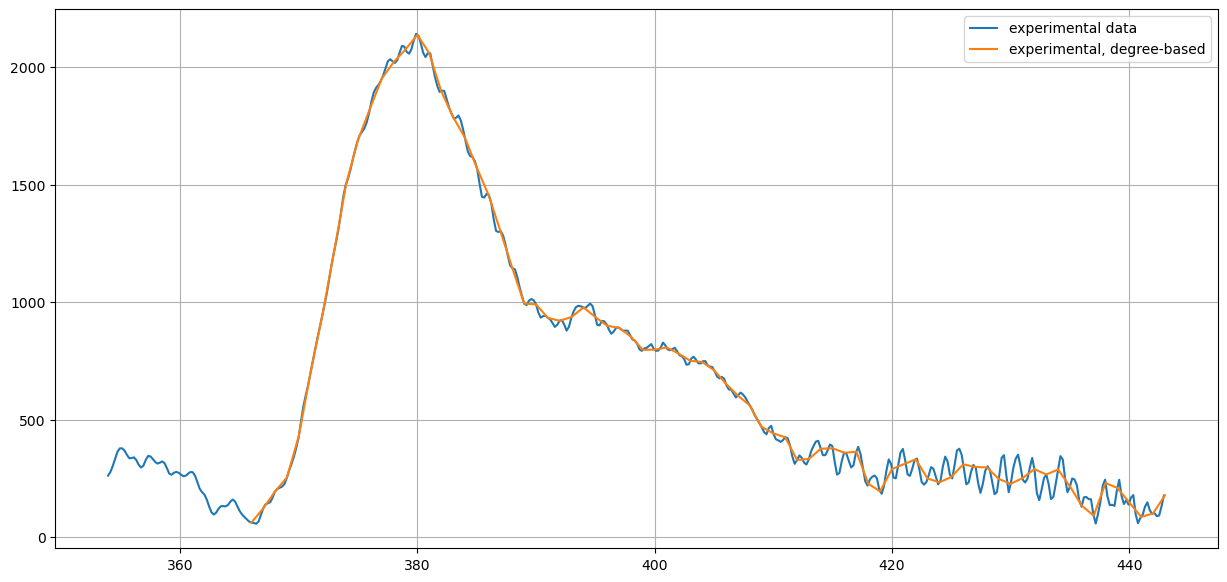

In [56]:
interval = np.arange(2650, 3100)

fig, ax = plt.subplots(figsize=(15, 7))
plt.plot(Fi[interval], dQcdFi[interval], label='experimental data')
plt.plot(fi, dQcdFi_tab, label='experimental, degree-based')
plt.grid()
plt.legend()
plt.show()

Heat release rate:

$$
\frac{dQ_{comb}}{d\phi} = H_u \frac{dx}{d\phi} q_c
$$

Plot of  $ \dfrac{dx}{d\phi} $ versus crank angle

It is necessary to store **dXdFi** in a separate variable over the interval where combustion takes place.

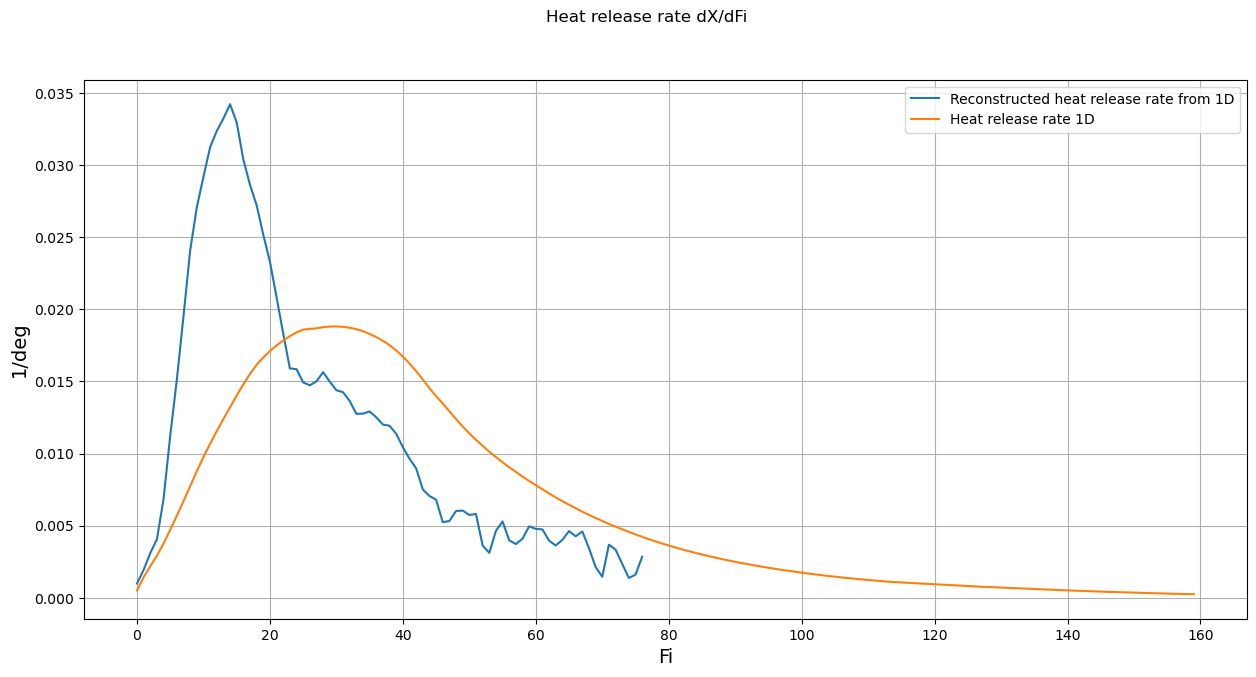

In [57]:
dXdFi_tab = dQcdFi_tab / (Hu * qc)

fig, ax = plt.subplots(figsize=(15, 7))
plt.suptitle('Heat release rate dX/dFi')
plt.plot(dXdFi_tab, label='Reconstructed heat release rate from 1D')
plt.plot(np.gradient(HR)[HR > 0][:-1], label='Heat release rate 1D')
plt.ylabel('1/deg', fontsize=14)
plt.xlabel('Fi', fontsize=14)
plt.grid('on')
plt.legend()
plt.show()

## 3. Using the double Wiebe function for combustion modeling

For a diesel engine, it can be written in the following form:

$$
\frac{dx_{dies}}{d\phi} = \frac{dx_{prem}}{d\phi} + \frac{dx_{diff}}{d\phi}
$$

For premixed combustion:

$$
\frac{dx_{prem}}{d\phi} =
\chi_t
\left[\frac{m_t}{\phi_{comb}}\right]
\left[\frac{\phi}{\phi_{comb}}\right]
\exp\left(
-\frac{m_t}{m_t+1}
\left[\frac{\phi}{\phi_{comb}}\right]^{m_t+1}
\right)
$$

For diffusion combustion:

$$
\frac{dx_{diff}}{d\phi} =
(1-\chi_t)\, C
\left[\frac{m_v+1}{\phi_z}\right]
\left[\frac{\phi}{\phi_z}\right]
\exp\left(
-C\left[\frac{\phi}{\phi_z}\right]^{m_v+1}
\right)
$$

$ \chi_t $ — fraction of fuel burned by the kinetic mechanism;

$ m_t $ — kinetic combustion shape factor;

$ \phi_{comb} $ — crank angle corresponding to the maximum rate of kinetic combustion;

$ m_v $ — volumetric combustion shape factor;

$ C = -\ln[1-\Delta x] $

$ \Delta x $ — fraction of fuel burned over the entire process (usually taken as approximately 0.99);

$ \phi_z $ — total combustion duration.

It is necessary to determine the constants, except for those that can be taken directly from the plot.

In [58]:
ksi=0.03
dx=0.99
mt=2
mv=0.85
Fiz=13                       # get from hrr
Fic=77                       # get from hrr 
C=-np.log(1-dx)

Write a function to determine the heat release rate.

In [59]:
def hrr (Fi, ksi, mt, mv, Fic):
    KiN = (mt/Fiz)*(Fi/Fiz)**mt*np.exp(-mt/(mt+1)*(Fi/Fiz)**(mt+1))
    Dif = C*((mv+1)/Fic)*(Fi/Fic)**mv*np.exp(-C*(Fi/Fic)**(mv+1))
    return (ksi*KiN+(1-ksi)*Dif)

In [60]:
Fi = np.linspace(0, 125, 125)
dXdFicalc = hrr (Fi, ksi, mt, mv, Fic)

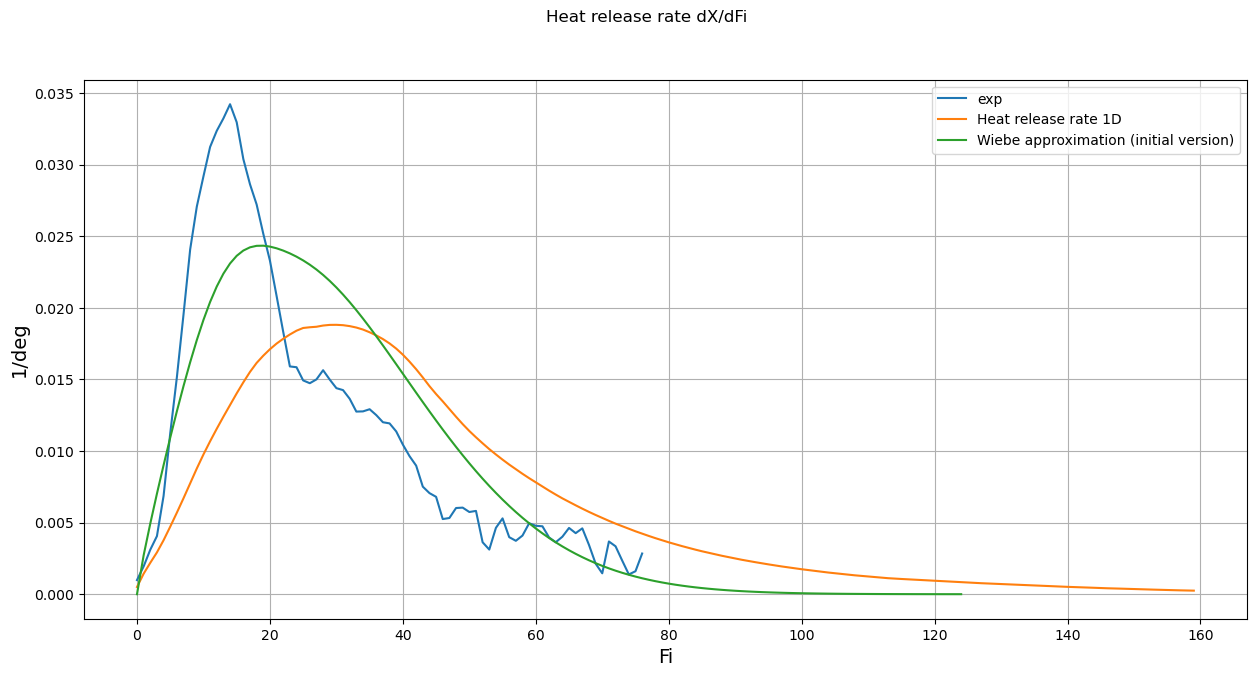

In [61]:
fig, ax = plt.subplots(figsize=(15, 7))
plt.suptitle('Heat release rate dX/dFi')
plt.plot(dXdFi_tab, label='exp')
plt.plot(np.gradient(HR)[HR > 0][:-1], label='Heat release rate 1D')
plt.plot(dXdFicalc, label='Wiebe approximation (initial version)')
plt.ylabel('1/deg', fontsize=14)
plt.xlabel('Fi', fontsize=14)
plt.grid('on')
plt.legend()
plt.show()

This does not seem to be the optimal solution

### Fitting the coefficients in the Wiebe function

This approach is not entirely correct, because the purpose of using the Wiebe function is to generalize the data. However, to demonstrate the capabilities of Python, we can try to determine the parameters that would allow the heat release characteristic in this particular case to be approximated as accurately as possible.

Initial value vector

In [62]:
X0 = [ksi, mt, mv, Fic]
X0

[0.03, 2, 0.85, 77]

Definition of the objective function

In [63]:
def target(X):
    Fi = np.linspace(0, 77, 77)
    ksi =X[0] 
    mt = X[1]
    mv = X[2]
    Fic = X[3]
    tag = hrr (Fi, ksi, mt, mv, Fic) - dXdFi_tab
    return np.linalg.norm(tag)

Minimization of the objective function  

In [64]:
bounds = [(0, None), (0, None), (0, None), (0, None)] 
res = minimize(target, X0, bounds=bounds, method="SLSQP")
res 

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.01802444709707942
           x: [ 2.765e-01  2.074e+00  9.454e-01  7.701e+01]
         nit: 7
         jac: [-4.496e-04 -2.536e-04 -1.385e-05 -5.664e-04]
        nfev: 37
        njev: 7
 multipliers: []

Final coefficient values

In [65]:
ksi =res.x[0] 
mt = res.x[1] 
mv = res.x[2] 
Fic = res.x[3] 
print ('ksi = ', ksi)
print ('mt = ', mt)
print ('mv = ', mv)
print ('Fic = ', Fic)

ksi =  0.27653607459136387
mt =  2.073676225016356
mv =  0.9454477944600709
Fic =  77.01216527250561


In [66]:
Fi = np.linspace(0, 125, 125)
dXdFicalc_opt = hrr (Fi, ksi, mt, mv, Fic)

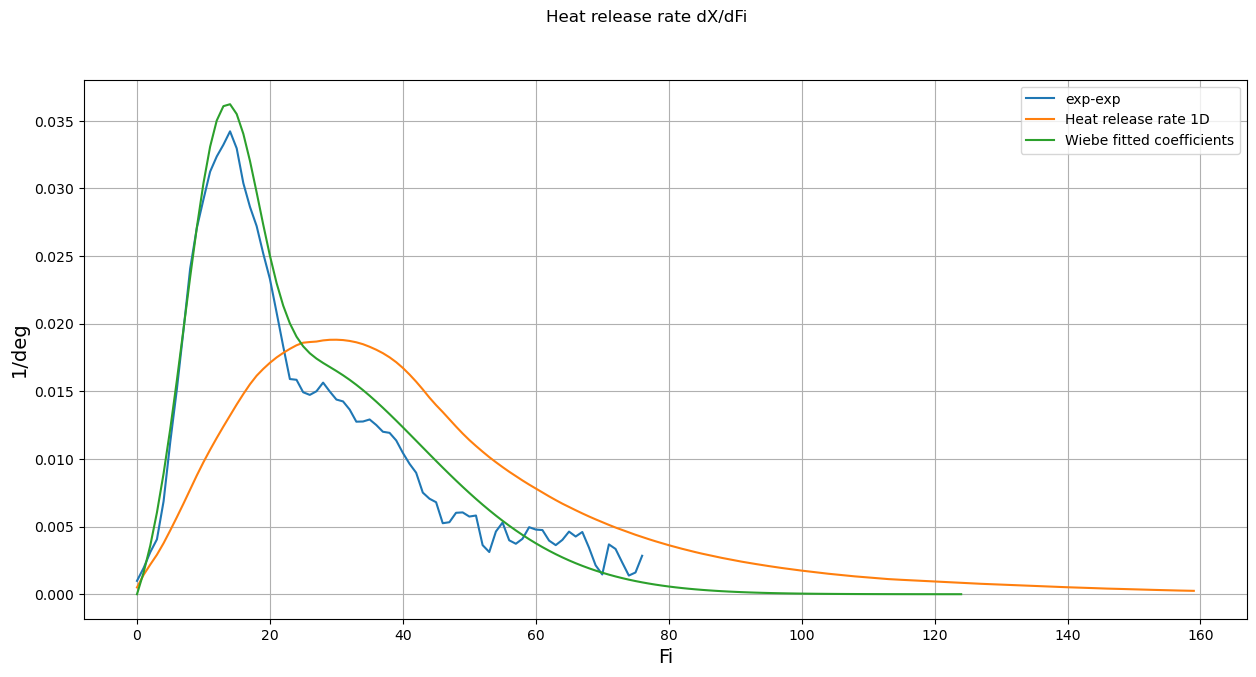

In [67]:
fig, ax = plt.subplots(figsize=(15, 7))
plt.suptitle('Heat release rate dX/dFi')
plt.plot(dXdFi_tab, label='exp-exp')
plt.plot(np.gradient(HR)[HR > 0][:-1], label='Heat release rate 1D')
plt.plot(dXdFicalc_opt, label='Wiebe fitted coefficients')
plt.ylabel('1/deg', fontsize=14)
plt.xlabel('Fi', fontsize=14)
plt.grid()
plt.legend()
plt.show()